In [ ]:
# Load libraries
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
# Read in AU-Preston observations
au_preston_obs = xr.open_dataset("/cluster/home/katepp/Urban-PLUMBER/AU-Preston/timeseries/AU-Preston_clean_observations_v1.nc")
au_preston_obs = au_preston_obs.sel(time=slice('2003-08-12', '2004-10-31'))

In [3]:
# Calculate observed net radiation
au_preston_obs_lwd = au_preston_obs.LWdown
au_preston_obs_lwu = au_preston_obs.LWup
au_preston_obs_swd = au_preston_obs.SWdown
au_preston_obs_swu = au_preston_obs.SWup

# Make missing observed SWup 0 when SWdown is below 5 Wm-2 (at night) to get full diurnal cycle of Rnet and G residual
use_zero = (
    au_preston_obs_swu.isnull() 
    & ~au_preston_obs_swd.isnull()
    & (au_preston_obs_swd <= 5)
)

# Fill with 0 where condition is True, keep original SWup_obs elsewhere
au_preston_swu_for_rnet = xr.where(use_zero, 0, au_preston_obs_swu)

au_preston_obs_rnet = au_preston_obs_lwd - au_preston_obs_lwu + au_preston_obs_swd - au_preston_swu_for_rnet

In [4]:
# Read in current simulation
au_preston_current = xr.open_dataset("/cluster/work/climate/kepp/icon-mpim/experiments/land_jsbach_sitelevel_current_au-preston/land_jsbach_sitelevel_current_au-preston_lnd_basic_au-preston_ml_19930101T000000Z.nc")
au_preston_current = au_preston_current.sel(time=slice('2003-08-12', '2004-10-31'))

In [6]:
# Get current simulated net radiation
au_preston_current_rnet = au_preston_current.rad_rad_srf_net_box

In [7]:
# Read in hcc simulation
au_preston_hcc = xr.open_dataset("/cluster/work/climate/kepp/urban_implementation/icon-mpim/experiments/land_jsbach_sitelevel_hcc_au-preston/land_jsbach_sitelevel_hcc_au-preston_lnd_basic_au-preston_ml_19930101T000000Z.nc")
au_preston_hcc = au_preston_hcc.sel(time=slice('2003-08-12', '2004-10-31'))

In [8]:
# Get hcc simulated net radiation
au_preston_hcc_rnet = au_preston_hcc.rad_rad_srf_net_box

In [9]:
# Read in hyd simulation
au_preston_hyd = xr.open_dataset("/cluster/work/climate/kepp/urban_implementation/icon-mpim/experiments/land_jsbach_sitelevel_hyd_au-preston/land_jsbach_sitelevel_hyd_au-preston_lnd_basic_au-preston_ml_19930101T000000Z.nc")
au_preston_hyd = au_preston_hyd.sel(time=slice('2003-08-12', '2004-10-31'))

In [10]:
# Get hyd simulated net radiation
au_preston_hyd_rnet = au_preston_hyd.rad_rad_srf_net_box

In [11]:
# Read in hcc_hyd simulation
au_preston_hcc_hyd = xr.open_dataset("/cluster/work/climate/kepp/urban_implementation/icon-mpim/experiments/land_jsbach_sitelevel_hcc_hyd_au-preston/land_jsbach_sitelevel_hcc_hyd_au-preston_lnd_basic_au-preston_ml_19930101T000000Z.nc")
au_preston_hcc_hyd = au_preston_hcc_hyd.sel(time=slice('2003-08-12', '2004-10-31'))

In [12]:
# Get hcc_hyd simulated net radiation
au_preston_hcc_hyd_rnet = au_preston_hcc_hyd.rad_rad_srf_net_box

In [13]:
# Calculate mean diurnal cycle for DJF
# Filter by DJF
is_djf_obs = au_preston_obs_rnet.time.dt.month.isin([12, 1, 2])
au_preston_obs_rnet_djf = au_preston_obs_rnet.sel(time=is_djf_obs)

is_djf_current = au_preston_current_rnet.time.dt.month.isin([12, 1, 2])
au_preston_current_rnet_djf = au_preston_current_rnet.sel(time=is_djf_current)

is_djf_hcc = au_preston_hcc_rnet.time.dt.month.isin([12, 1, 2])
au_preston_hcc_rnet_djf = au_preston_hcc_rnet.sel(time=is_djf_hcc)

is_djf_hyd = au_preston_hyd_rnet.time.dt.month.isin([12, 1, 2])
au_preston_hyd_rnet_djf = au_preston_hyd_rnet.sel(time=is_djf_hyd)

is_djf_hcc_hyd = au_preston_hcc_hyd_rnet.time.dt.month.isin([12, 1, 2])
au_preston_hcc_hyd_rnet_djf = au_preston_hcc_hyd_rnet.sel(time=is_djf_hcc_hyd)

# Convert to local time
local_time_index = (
    au_preston_obs_rnet_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_obs_rnet_djf["time"] = local_time_index.tz_localize(None) + np.timedelta64(30, "m") # add 30 min to account for period-ending timestamps of observations

local_time_index = (
    au_preston_current_rnet_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_current_rnet_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_rnet_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_rnet_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hyd_rnet_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hyd_rnet_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_hyd_rnet_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_hyd_rnet_djf["time"] = local_time_index.tz_localize(None)


# Calculate mean diurnal cycle
au_preston_obs_rnet_djf_diurnal = au_preston_obs_rnet_djf.groupby("time.hour").mean()

au_preston_current_rnet_djf_diurnal = au_preston_current_rnet_djf.groupby("time.hour").mean()

au_preston_hcc_rnet_djf_diurnal = au_preston_hcc_rnet_djf.groupby("time.hour").mean()

au_preston_hyd_rnet_djf_diurnal = au_preston_hyd_rnet_djf.groupby("time.hour").mean()

au_preston_hcc_hyd_rnet_djf_diurnal = au_preston_hcc_hyd_rnet_djf.groupby("time.hour").mean()

In [14]:
# Calculate mean diurnal cycle for JJA
# Filter by JJA
is_jja_obs = au_preston_obs_rnet.time.dt.month.isin([6, 7, 8])
au_preston_obs_rnet_jja = au_preston_obs_rnet.sel(time=is_jja_obs)

is_jja_current = au_preston_current_rnet.time.dt.month.isin([6, 7, 8])
au_preston_current_rnet_jja = au_preston_current_rnet.sel(time=is_jja_current)

is_jja_hcc = au_preston_hcc_rnet.time.dt.month.isin([6, 7, 8])
au_preston_hcc_rnet_jja = au_preston_hcc_rnet.sel(time=is_jja_hcc)

is_jja_hyd = au_preston_hyd_rnet.time.dt.month.isin([6, 7, 8])
au_preston_hyd_rnet_jja = au_preston_hyd_rnet.sel(time=is_jja_hyd)

is_jja_hcc_hyd = au_preston_hcc_hyd_rnet.time.dt.month.isin([6, 7, 8])
au_preston_hcc_hyd_rnet_jja = au_preston_hcc_hyd_rnet.sel(time=is_jja_hcc_hyd)


# Convert to local time
local_time_index = (
    au_preston_obs_rnet_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_obs_rnet_jja["time"] = local_time_index.tz_localize(None) + np.timedelta64(30, "m") # add 30 min to account for period-ending timestamps of observations

local_time_index = (
    au_preston_current_rnet_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_current_rnet_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_rnet_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_rnet_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hyd_rnet_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hyd_rnet_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_hyd_rnet_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_hyd_rnet_jja["time"] = local_time_index.tz_localize(None)


# Calculate mean diurnal cycle
au_preston_obs_rnet_jja_diurnal = au_preston_obs_rnet_jja.groupby("time.hour").mean()

au_preston_current_rnet_jja_diurnal = au_preston_current_rnet_jja.groupby("time.hour").mean()

au_preston_hcc_rnet_jja_diurnal = au_preston_hcc_rnet_jja.groupby("time.hour").mean()

au_preston_hyd_rnet_jja_diurnal = au_preston_hyd_rnet_jja.groupby("time.hour").mean()

au_preston_hcc_hyd_rnet_jja_diurnal = au_preston_hcc_hyd_rnet_jja.groupby("time.hour").mean()

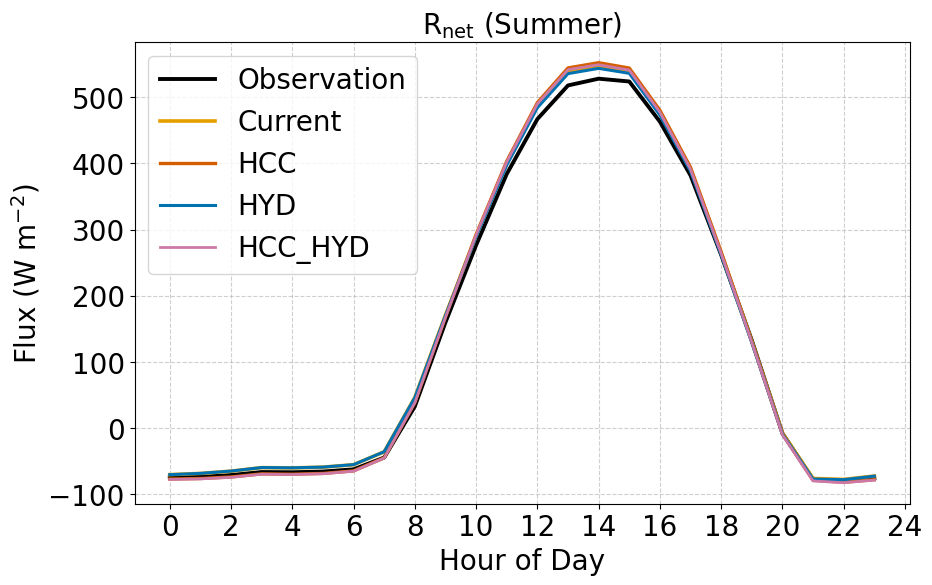

In [15]:
# Plot observations and simulations for Rnet DJF

plt.figure(figsize=(10, 6))
au_preston_obs_rnet_djf_diurnal.plot(label='Observation', color='black', linewidth=2.8)
au_preston_current_rnet_djf_diurnal.plot(label='Current', color="#E69F00", linewidth=2.6)
au_preston_hcc_rnet_djf_diurnal.plot(label='HCC', color="#D55E00", linewidth=2.4)
au_preston_hyd_rnet_djf_diurnal.plot(label='HYD', color="#0072B2", linewidth=2.2)
au_preston_hcc_hyd_rnet_djf_diurnal.plot(label='HCC_HYD', color="#CC79A7", linewidth=2)
plt.title(r"${\mathrm{R_{net}}}$ (Summer)", fontsize=20)
plt.xlabel("Hour of Day", fontsize=20)
plt.ylabel(r"Flux (W m$^{-2}$)", fontsize=20)
plt.xticks(range(0, 25, 2), fontsize=20) # Ensure labels every 2 hours
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=20)
plt.show()

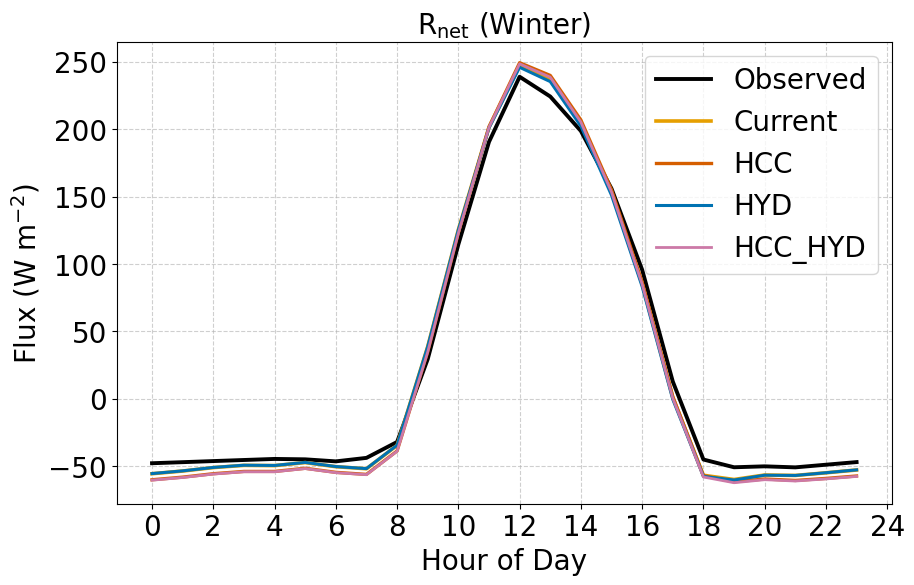

In [16]:
# Plot observations and simulations for Rnet JJA

plt.figure(figsize=(10, 6))
au_preston_obs_rnet_jja_diurnal.plot(label='Observed', color='black', linewidth=2.8)
au_preston_current_rnet_jja_diurnal.plot(label='Current', color="#E69F00", linewidth=2.6)
au_preston_hcc_rnet_jja_diurnal.plot(label='HCC', color="#D55E00", linewidth=2.4)
au_preston_hyd_rnet_jja_diurnal.plot(label='HYD', color="#0072B2", linewidth=2.2)
au_preston_hcc_hyd_rnet_jja_diurnal.plot(label='HCC_HYD', color="#CC79A7", linewidth=2)
plt.title(r"${\mathrm{R_{net}}}$ (Winter)", fontsize=20)
plt.xlabel("Hour of Day", fontsize=20)
plt.ylabel(r"Flux (W m$^{-2}$)", fontsize=20)
plt.xticks(range(0, 25, 2), fontsize=20) # Ensure labels every 2 hours
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=20)
plt.show()

In [17]:
# Get observed sensible heat flux
au_preston_obs_qh = au_preston_obs.Qh

In [18]:
# Get current simulated sensible heat flux
au_preston_current_qh = - au_preston_current.seb_sensible_hflx_box

In [19]:
# Get hcc simulated sensible heat flux
au_preston_hcc_qh = - au_preston_hcc.seb_sensible_hflx_box

In [20]:
# Get hyd simulated sensible heat flux
au_preston_hyd_qh = - au_preston_hyd.seb_sensible_hflx_box

In [21]:
# Get hcc_hyd simulated sensible heat flux
au_preston_hcc_hyd_qh = - au_preston_hcc_hyd.seb_sensible_hflx_box

In [22]:
# Calculate mean diurnal cycle for DJF
# Filter by DJF
is_djf_obs = au_preston_obs_qh.time.dt.month.isin([12, 1, 2])
au_preston_obs_qh_djf = au_preston_obs_qh.sel(time=is_djf_obs)

is_djf_current = au_preston_current_qh.time.dt.month.isin([12, 1, 2])
au_preston_current_qh_djf = au_preston_current_qh.sel(time=is_djf_current)

is_djf_hcc = au_preston_hcc_qh.time.dt.month.isin([12, 1, 2])
au_preston_hcc_qh_djf = au_preston_hcc_qh.sel(time=is_djf_hcc)

is_djf_hyd = au_preston_hyd_qh.time.dt.month.isin([12, 1, 2])
au_preston_hyd_qh_djf = au_preston_hyd_qh.sel(time=is_djf_hyd)

is_djf_hcc_hyd = au_preston_hcc_hyd_qh.time.dt.month.isin([12, 1, 2])
au_preston_hcc_hyd_qh_djf = au_preston_hcc_hyd_qh.sel(time=is_djf_hcc_hyd)

# Convert to local time
local_time_index = (
    au_preston_obs_qh_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_obs_qh_djf["time"] = local_time_index.tz_localize(None) + np.timedelta64(30, "m") # add 30 min to account for period-ending timestamps of observations

local_time_index = (
    au_preston_current_qh_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_current_qh_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_qh_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_qh_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hyd_qh_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hyd_qh_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_hyd_qh_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_hyd_qh_djf["time"] = local_time_index.tz_localize(None)


# Calculate mean diurnal cycle
au_preston_obs_qh_djf_diurnal = au_preston_obs_qh_djf.groupby("time.hour").mean()

au_preston_current_qh_djf_diurnal = au_preston_current_qh_djf.groupby("time.hour").mean()

au_preston_hcc_qh_djf_diurnal = au_preston_hcc_qh_djf.groupby("time.hour").mean()

au_preston_hyd_qh_djf_diurnal = au_preston_hyd_qh_djf.groupby("time.hour").mean()

au_preston_hcc_hyd_qh_djf_diurnal = au_preston_hcc_hyd_qh_djf.groupby("time.hour").mean()

In [23]:
# Calculate mean diurnal cycle for JJA
# Filter by JJA
is_jja_obs = au_preston_obs_qh.time.dt.month.isin([6, 7, 8])
au_preston_obs_qh_jja = au_preston_obs_qh.sel(time=is_jja_obs)

is_jja_current = au_preston_current_qh.time.dt.month.isin([6, 7, 8])
au_preston_current_qh_jja = au_preston_current_qh.sel(time=is_jja_current)

is_jja_hcc = au_preston_hcc_qh.time.dt.month.isin([6, 7, 8])
au_preston_hcc_qh_jja = au_preston_hcc_qh.sel(time=is_jja_hcc)

is_jja_hyd = au_preston_hyd_qh.time.dt.month.isin([6, 7, 8])
au_preston_hyd_qh_jja = au_preston_hyd_qh.sel(time=is_jja_hyd)

is_jja_hcc_hyd = au_preston_hcc_hyd_qh.time.dt.month.isin([6, 7, 8])
au_preston_hcc_hyd_qh_jja = au_preston_hcc_hyd_qh.sel(time=is_jja_hcc_hyd)


# Convert to local time
local_time_index = (
    au_preston_obs_qh_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_obs_qh_jja["time"] = local_time_index.tz_localize(None) + np.timedelta64(30, "m") # add 30 min to account for period-ending timestamps of observations

local_time_index = (
    au_preston_current_qh_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_current_qh_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_qh_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_qh_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hyd_qh_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hyd_qh_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_hyd_qh_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_hyd_qh_jja["time"] = local_time_index.tz_localize(None)


# Calculate mean diurnal cycle
au_preston_obs_qh_jja_diurnal = au_preston_obs_qh_jja.groupby("time.hour").mean()

au_preston_current_qh_jja_diurnal = au_preston_current_qh_jja.groupby("time.hour").mean()

au_preston_hcc_qh_jja_diurnal = au_preston_hcc_qh_jja.groupby("time.hour").mean()

au_preston_hyd_qh_jja_diurnal = au_preston_hyd_qh_jja.groupby("time.hour").mean()

au_preston_hcc_hyd_qh_jja_diurnal = au_preston_hcc_hyd_qh_jja.groupby("time.hour").mean()

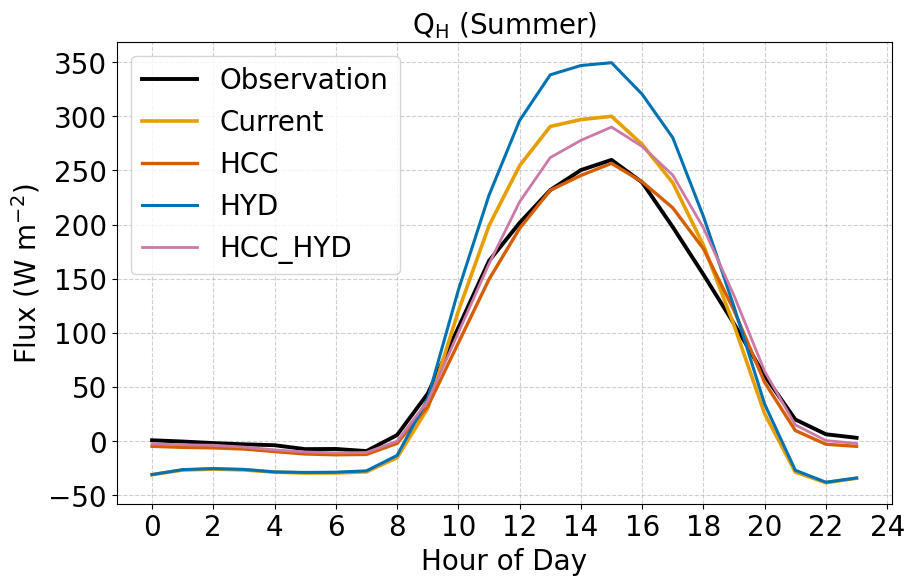

In [24]:
# Plot observations and simulations for QH DJF

plt.figure(figsize=(10, 6))
au_preston_obs_qh_djf_diurnal.plot(label='Observation', color='black', linewidth=2.8)
au_preston_current_qh_djf_diurnal.plot(label='Current', color="#E69F00", linewidth=2.6)
au_preston_hcc_qh_djf_diurnal.plot(label='HCC', color="#D55E00", linewidth=2.4)
au_preston_hyd_qh_djf_diurnal.plot(label='HYD', color="#0072B2", linewidth=2.2)
au_preston_hcc_hyd_qh_djf_diurnal.plot(label='HCC_HYD', color="#CC79A7", linewidth=2)
plt.title(r"${\mathrm{Q_{H}}}$ (Summer)", fontsize=20)
plt.xlabel("Hour of Day", fontsize=20)
plt.ylabel(r"Flux (W m$^{-2}$)", fontsize=20)
plt.xticks(range(0, 25, 2), fontsize=20) # Ensure labels every 2 hours
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=20)
plt.show()

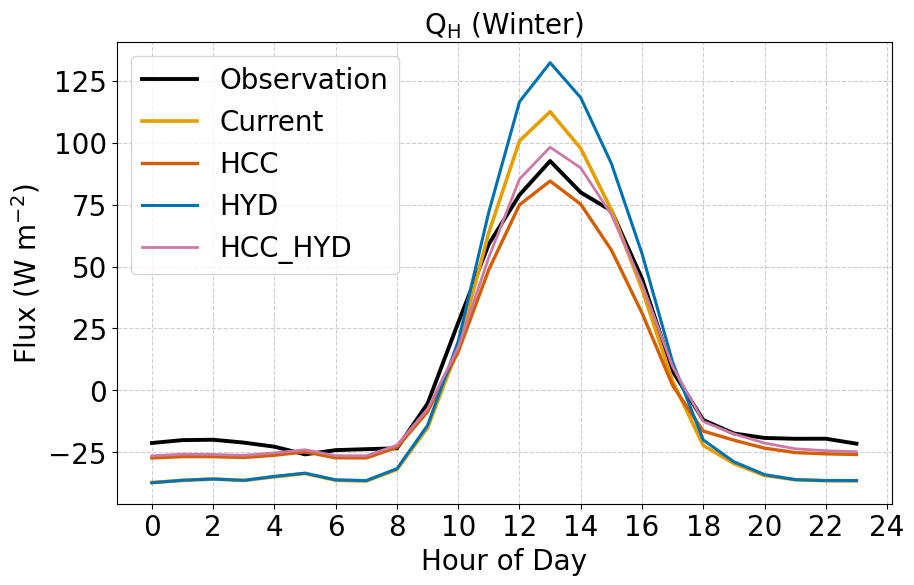

In [25]:
# Plot observations and simulations for QH JJA

plt.figure(figsize=(10, 6))
au_preston_obs_qh_jja_diurnal.plot(label='Observation', color='black', linewidth=2.8)
au_preston_current_qh_jja_diurnal.plot(label='Current', color="#E69F00", linewidth=2.6)
au_preston_hcc_qh_jja_diurnal.plot(label='HCC', color="#D55E00", linewidth=2.4)
au_preston_hyd_qh_jja_diurnal.plot(label='HYD', color="#0072B2", linewidth=2.2)
au_preston_hcc_hyd_qh_jja_diurnal.plot(label='HCC_HYD', color="#CC79A7", linewidth=2)
plt.title(r"${\mathrm{Q_{H}}}$ (Winter)", fontsize=20)
plt.xlabel("Hour of Day", fontsize=20)
plt.ylabel(r"Flux (W m$^{-2}$)", fontsize=20)
plt.xticks(range(0, 25, 2), fontsize=20) # Ensure labels every 2 hours
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=20)
plt.show()

In [26]:
# Get observed latent heat flux
au_preston_obs_qle = au_preston_obs.Qle

In [27]:
# Get current simulated latent heat flux
au_preston_current_qle = - au_preston_current.seb_latent_hflx_box

In [28]:
# Get hcc simulated latent heat flux
au_preston_hcc_qle = - au_preston_hcc.seb_latent_hflx_box

In [29]:
# Get hyd simulated latent heat flux
au_preston_hyd_qle = - au_preston_hyd.seb_latent_hflx_box

In [30]:
# Get hcc & hyd simulated latent heat flux
au_preston_hcc_hyd_qle = - au_preston_hcc_hyd.seb_latent_hflx_box

In [31]:
# Calculate mean diurnal cycle for DJF
# Filter by DJF
is_djf_obs = au_preston_obs_qle.time.dt.month.isin([12, 1, 2])
au_preston_obs_qle_djf = au_preston_obs_qle.sel(time=is_djf_obs)

is_djf_current = au_preston_current_qle.time.dt.month.isin([12, 1, 2])
au_preston_current_qle_djf = au_preston_current_qle.sel(time=is_djf_current)

is_djf_hcc = au_preston_hcc_qle.time.dt.month.isin([12, 1, 2])
au_preston_hcc_qle_djf = au_preston_hcc_qle.sel(time=is_djf_hcc)

is_djf_hyd = au_preston_hyd_qle.time.dt.month.isin([12, 1, 2])
au_preston_hyd_qle_djf = au_preston_hyd_qle.sel(time=is_djf_hyd)

is_djf_hcc_hyd = au_preston_hcc_hyd_qle.time.dt.month.isin([12, 1, 2])
au_preston_hcc_hyd_qle_djf = au_preston_hcc_hyd_qle.sel(time=is_djf_hcc_hyd)


# Convert to local time
local_time_index = (
    au_preston_obs_qle_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_obs_qle_djf["time"] = local_time_index.tz_localize(None) + np.timedelta64(30, "m") # add 30 min to account for period-ending timestamps of observations

local_time_index = (
    au_preston_current_qle_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_current_qle_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_qle_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_qle_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hyd_qle_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hyd_qle_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_hyd_qle_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_hyd_qle_djf["time"] = local_time_index.tz_localize(None)


# Calculate mean diurnal cycle
au_preston_obs_qle_djf_diurnal = au_preston_obs_qle_djf.groupby("time.hour").mean()

au_preston_current_qle_djf_diurnal = au_preston_current_qle_djf.groupby("time.hour").mean()

au_preston_hcc_qle_djf_diurnal = au_preston_hcc_qle_djf.groupby("time.hour").mean()

au_preston_hyd_qle_djf_diurnal = au_preston_hyd_qle_djf.groupby("time.hour").mean()

au_preston_hcc_hyd_qle_djf_diurnal = au_preston_hcc_hyd_qle_djf.groupby("time.hour").mean()

In [32]:
# Calculate mean diurnal cycle for JJA
# Filter by JJA
is_jja_obs = au_preston_obs_qle.time.dt.month.isin([6, 7, 8])
au_preston_obs_qle_jja = au_preston_obs_qle.sel(time=is_jja_obs)

is_jja_current = au_preston_current_qle.time.dt.month.isin([6, 7, 8])
au_preston_current_qle_jja = au_preston_current_qle.sel(time=is_jja_current)

is_jja_hcc = au_preston_hcc_qle.time.dt.month.isin([6, 7, 8])
au_preston_hcc_qle_jja = au_preston_hcc_qle.sel(time=is_jja_hcc)

is_jja_hyd = au_preston_hyd_qle.time.dt.month.isin([6, 7, 8])
au_preston_hyd_qle_jja = au_preston_hyd_qle.sel(time=is_jja_hyd)

is_jja_hcc_hyd = au_preston_hcc_hyd_qle.time.dt.month.isin([6, 7, 8])
au_preston_hcc_hyd_qle_jja = au_preston_hcc_hyd_qle.sel(time=is_jja_hcc_hyd)


# Convert to local time
local_time_index = (
    au_preston_obs_qle_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_obs_qle_jja["time"] = local_time_index.tz_localize(None) + np.timedelta64(30, "m") # add 30 min to account for period-ending timestamps of observations

local_time_index = (
    au_preston_current_qle_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_current_qle_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_qle_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_qle_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hyd_qle_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hyd_qle_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_hyd_qle_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_hyd_qle_jja["time"] = local_time_index.tz_localize(None)


# Calculate mean diurnal cycle
au_preston_obs_qle_jja_diurnal = au_preston_obs_qle_jja.groupby("time.hour").mean()

au_preston_current_qle_jja_diurnal = au_preston_current_qle_jja.groupby("time.hour").mean()

au_preston_hcc_qle_jja_diurnal = au_preston_hcc_qle_jja.groupby("time.hour").mean()

au_preston_hyd_qle_jja_diurnal = au_preston_hyd_qle_jja.groupby("time.hour").mean()

au_preston_hcc_hyd_qle_jja_diurnal = au_preston_hcc_hyd_qle_jja.groupby("time.hour").mean()

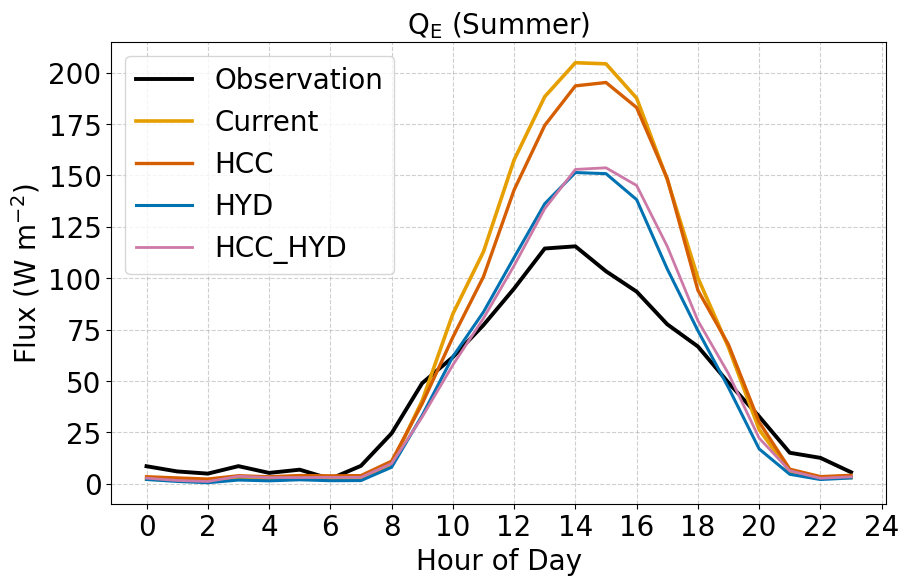

In [33]:
# Plot observations and simulations for QLE DJF

plt.figure(figsize=(10, 6))
au_preston_obs_qle_djf_diurnal.plot(label='Observation', color='black', linewidth=2.8)
au_preston_current_qle_djf_diurnal.plot(label='Current', color="#E69F00", linewidth=2.6)
au_preston_hcc_qle_djf_diurnal.plot(label='HCC', color="#D55E00", linewidth=2.4)
au_preston_hyd_qle_djf_diurnal.plot(label='HYD', color="#0072B2", linewidth=2.2)
au_preston_hcc_hyd_qle_djf_diurnal.plot(label='HCC_HYD', color="#CC79A7", linewidth=2)
plt.title(r"${\mathrm{Q_{E}}}$ (Summer)", fontsize=20)
plt.xlabel("Hour of Day", fontsize=20)
plt.ylabel(r"Flux (W m$^{-2}$)", fontsize=20)
plt.xticks(range(0, 25, 2), fontsize=20) # Ensure labels every 2 hours
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=20)
plt.show()

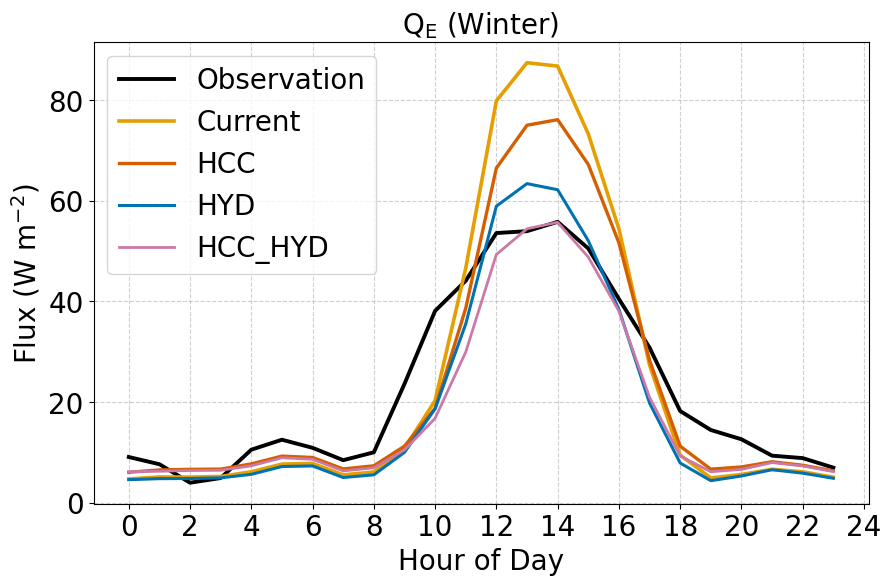

In [34]:
# Plot observations and simulations for QLE JJA

plt.figure(figsize=(10, 6))
au_preston_obs_qle_jja_diurnal.plot(label='Observation', color='black', linewidth=2.8)
au_preston_current_qle_jja_diurnal.plot(label='Current', color="#E69F00", linewidth=2.6)
au_preston_hcc_qle_jja_diurnal.plot(label='HCC', color="#D55E00", linewidth=2.4)
au_preston_hyd_qle_jja_diurnal.plot(label='HYD', color="#0072B2", linewidth=2.2)
au_preston_hcc_hyd_qle_jja_diurnal.plot(label='HCC_HYD', color="#CC79A7", linewidth=2)
plt.title(r"${\mathrm{Q_{E}}}$ (Winter)", fontsize=20)
plt.xlabel("Hour of Day", fontsize=20)
plt.ylabel(r"Flux (W m$^{-2}$)", fontsize=20)
plt.xticks(range(0, 25, 2), fontsize=20) # Ensure labels every 2 hours
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=20)
plt.show()

In [35]:
# Calculate observed residual
au_preston_obs_residual = au_preston_obs_rnet - au_preston_obs_qle - au_preston_obs_qh
au_preston_obs_residual = - au_preston_obs_residual # adjust sign to simulated ground heat flux

In [36]:
# Get current simulated ground heat flux
au_preston_current_qg = au_preston_current.sse_grnd_hflx_box

In [37]:
# Get hcc simulated ground heat flux
au_preston_hcc_qg = au_preston_hcc.sse_grnd_hflx_box

In [38]:
# Get hyd simulated ground heat flux
au_preston_hyd_qg = au_preston_hyd.sse_grnd_hflx_box

In [39]:
# Get hcc_hyd simulated ground heat flux
au_preston_hcc_hyd_qg = au_preston_hcc_hyd.sse_grnd_hflx_box

In [40]:
# Calculate mean diurnal cycle for DJF
# Filter by DJF
is_djf_obs = au_preston_obs_residual.time.dt.month.isin([12, 1, 2])
au_preston_obs_residual_djf = au_preston_obs_residual.sel(time=is_djf_obs)

is_djf_current = au_preston_current_qg.time.dt.month.isin([12, 1, 2])
au_preston_current_qg_djf = au_preston_current_qg.sel(time=is_djf_current)

is_djf_hcc = au_preston_hcc_qg.time.dt.month.isin([12, 1, 2])
au_preston_hcc_qg_djf = au_preston_hcc_qg.sel(time=is_djf_hcc)

is_djf_hyd = au_preston_hyd_qg.time.dt.month.isin([12, 1, 2])
au_preston_hyd_qg_djf = au_preston_hyd_qg.sel(time=is_djf_hyd)

is_djf_hcc_hyd = au_preston_hcc_hyd_qg.time.dt.month.isin([12, 1, 2])
au_preston_hcc_hyd_qg_djf = au_preston_hcc_hyd_qg.sel(time=is_djf_hcc_hyd)


# Convert to local time
local_time_index = (
    au_preston_obs_residual_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_obs_residual_djf["time"] = local_time_index.tz_localize(None) + np.timedelta64(30, "m") # add 30 min to account for period-ending timestamps of observations

local_time_index = (
    au_preston_current_qg_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_current_qg_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_qg_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_qg_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hyd_qg_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hyd_qg_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_hyd_qg_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_hyd_qg_djf["time"] = local_time_index.tz_localize(None)


# Calculate mean diurnal cycle
au_preston_obs_residual_djf_diurnal = au_preston_obs_residual_djf.groupby("time.hour").mean()

au_preston_current_qg_djf_diurnal = au_preston_current_qg_djf.groupby("time.hour").mean()

au_preston_hcc_qg_djf_diurnal = au_preston_hcc_qg_djf.groupby("time.hour").mean()

au_preston_hyd_qg_djf_diurnal = au_preston_hyd_qg_djf.groupby("time.hour").mean()

au_preston_hcc_hyd_qg_djf_diurnal = au_preston_hcc_hyd_qg_djf.groupby("time.hour").mean()

In [41]:
# Calculate mean diurnal cycle for JJA
# Filter by JJA
is_jja_obs = au_preston_obs_residual.time.dt.month.isin([6, 7, 8])
au_preston_obs_residual_jja = au_preston_obs_residual.sel(time=is_jja_obs)

is_jja_current = au_preston_current_qg.time.dt.month.isin([6, 7, 8])
au_preston_current_qg_jja = au_preston_current_qg.sel(time=is_jja_current)

is_jja_hcc = au_preston_hcc_qg.time.dt.month.isin([6, 7, 8])
au_preston_hcc_qg_jja = au_preston_hcc_qg.sel(time=is_jja_hcc)

is_jja_hyd = au_preston_hyd_qg.time.dt.month.isin([6, 7, 8])
au_preston_hyd_qg_jja = au_preston_hyd_qg.sel(time=is_jja_hyd)

is_jja_hcc_hyd = au_preston_hcc_hyd_qg.time.dt.month.isin([6, 7, 8])
au_preston_hcc_hyd_qg_jja = au_preston_hcc_hyd_qg.sel(time=is_jja_hcc_hyd)


# Convert to local time
local_time_index = (
    au_preston_obs_residual_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_obs_residual_jja["time"] = local_time_index.tz_localize(None) + np.timedelta64(30, "m") # add 30 min to account for period-ending timestamps of observations

local_time_index = (
    au_preston_current_qg_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_current_qg_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_qg_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_qg_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hyd_qg_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hyd_qg_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_hyd_qg_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_hyd_qg_jja["time"] = local_time_index.tz_localize(None)


# Calculate mean diurnal cycle
au_preston_obs_residual_jja_diurnal = au_preston_obs_residual_jja.groupby("time.hour").mean()

au_preston_current_qg_jja_diurnal = au_preston_current_qg_jja.groupby("time.hour").mean()

au_preston_hcc_qg_jja_diurnal = au_preston_hcc_qg_jja.groupby("time.hour").mean()

au_preston_hyd_qg_jja_diurnal = au_preston_hyd_qg_jja.groupby("time.hour").mean()

au_preston_hcc_hyd_qg_jja_diurnal = au_preston_hcc_hyd_qg_jja.groupby("time.hour").mean()

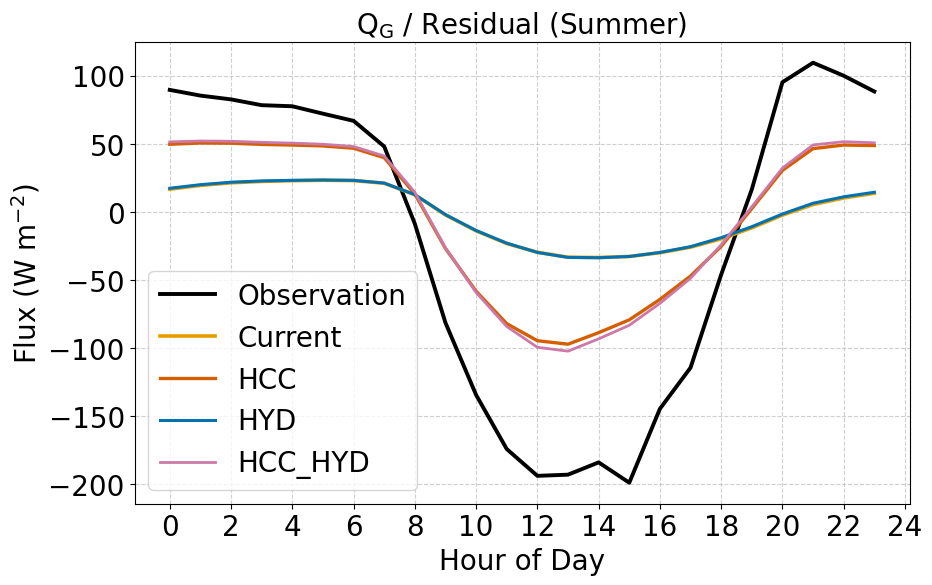

In [42]:
# Plot observations and simulations for QG DJF

plt.figure(figsize=(10, 6))
au_preston_obs_residual_djf_diurnal.plot(label='Observation', color="black", linewidth=2.8)
au_preston_current_qg_djf_diurnal.plot(label='Current', color="#E69F00", linewidth=2.6)
au_preston_hcc_qg_djf_diurnal.plot(label='HCC', color="#D55E00", linewidth=2.4)
au_preston_hyd_qg_djf_diurnal.plot(label='HYD', color="#0072B2", linewidth=2.2)
au_preston_hcc_hyd_qg_djf_diurnal.plot(label='HCC_HYD', color="#CC79A7", linewidth=2)
plt.title(r"${\mathrm{Q_{G}}}$ / Residual (Summer)", fontsize=20)
plt.xlabel("Hour of Day", fontsize=20)
plt.ylabel(r"Flux (W m$^{-2}$)", fontsize=20)
plt.xticks(range(0, 25, 2), fontsize=20) # Ensure labels every 2 hours
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=20)
plt.show()

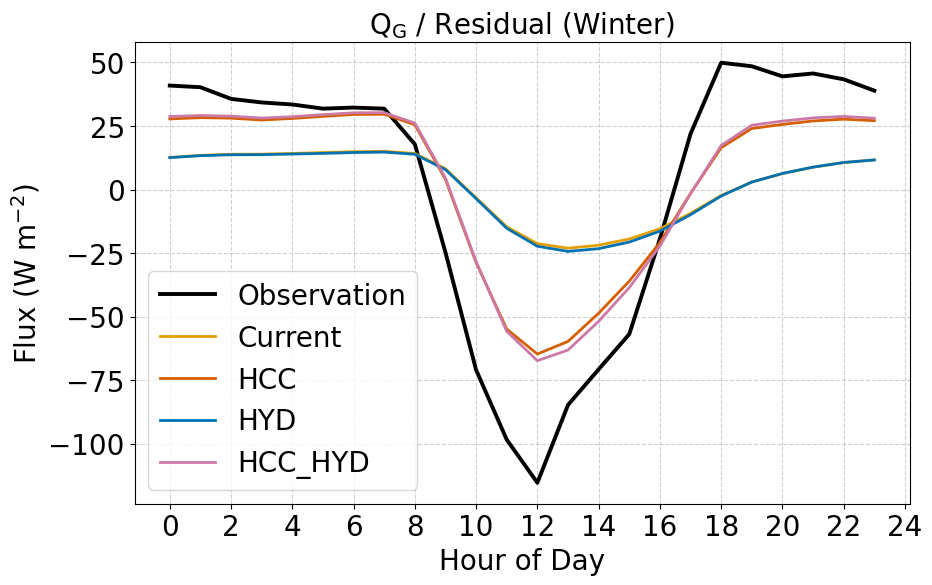

In [43]:
# Plot observations and simulations for QG JJA

plt.figure(figsize=(10, 6))
au_preston_obs_residual_jja_diurnal.plot(label='Observation', color="black", linewidth=2.8)
au_preston_current_qg_jja_diurnal.plot(label='Current', color="#E69F00", linewidth=2)
au_preston_hcc_qg_jja_diurnal.plot(label='HCC', color="#D55E00", linewidth=2)
au_preston_hyd_qg_jja_diurnal.plot(label='HYD', color="#0072B2", linewidth=2)
au_preston_hcc_hyd_qg_jja_diurnal.plot(label='HCC_HYD', color="#CC79A7", linewidth=2)
plt.title(r"${\mathrm{Q_{G}}}$ / Residual (Winter)", fontsize=20)
plt.xlabel("Hour of Day", fontsize=20)
plt.ylabel(r"Flux (W m$^{-2}$)", fontsize=20)
plt.xticks(range(0, 25, 2), fontsize=20) # Ensure labels every 2 hours
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=20)
plt.show()

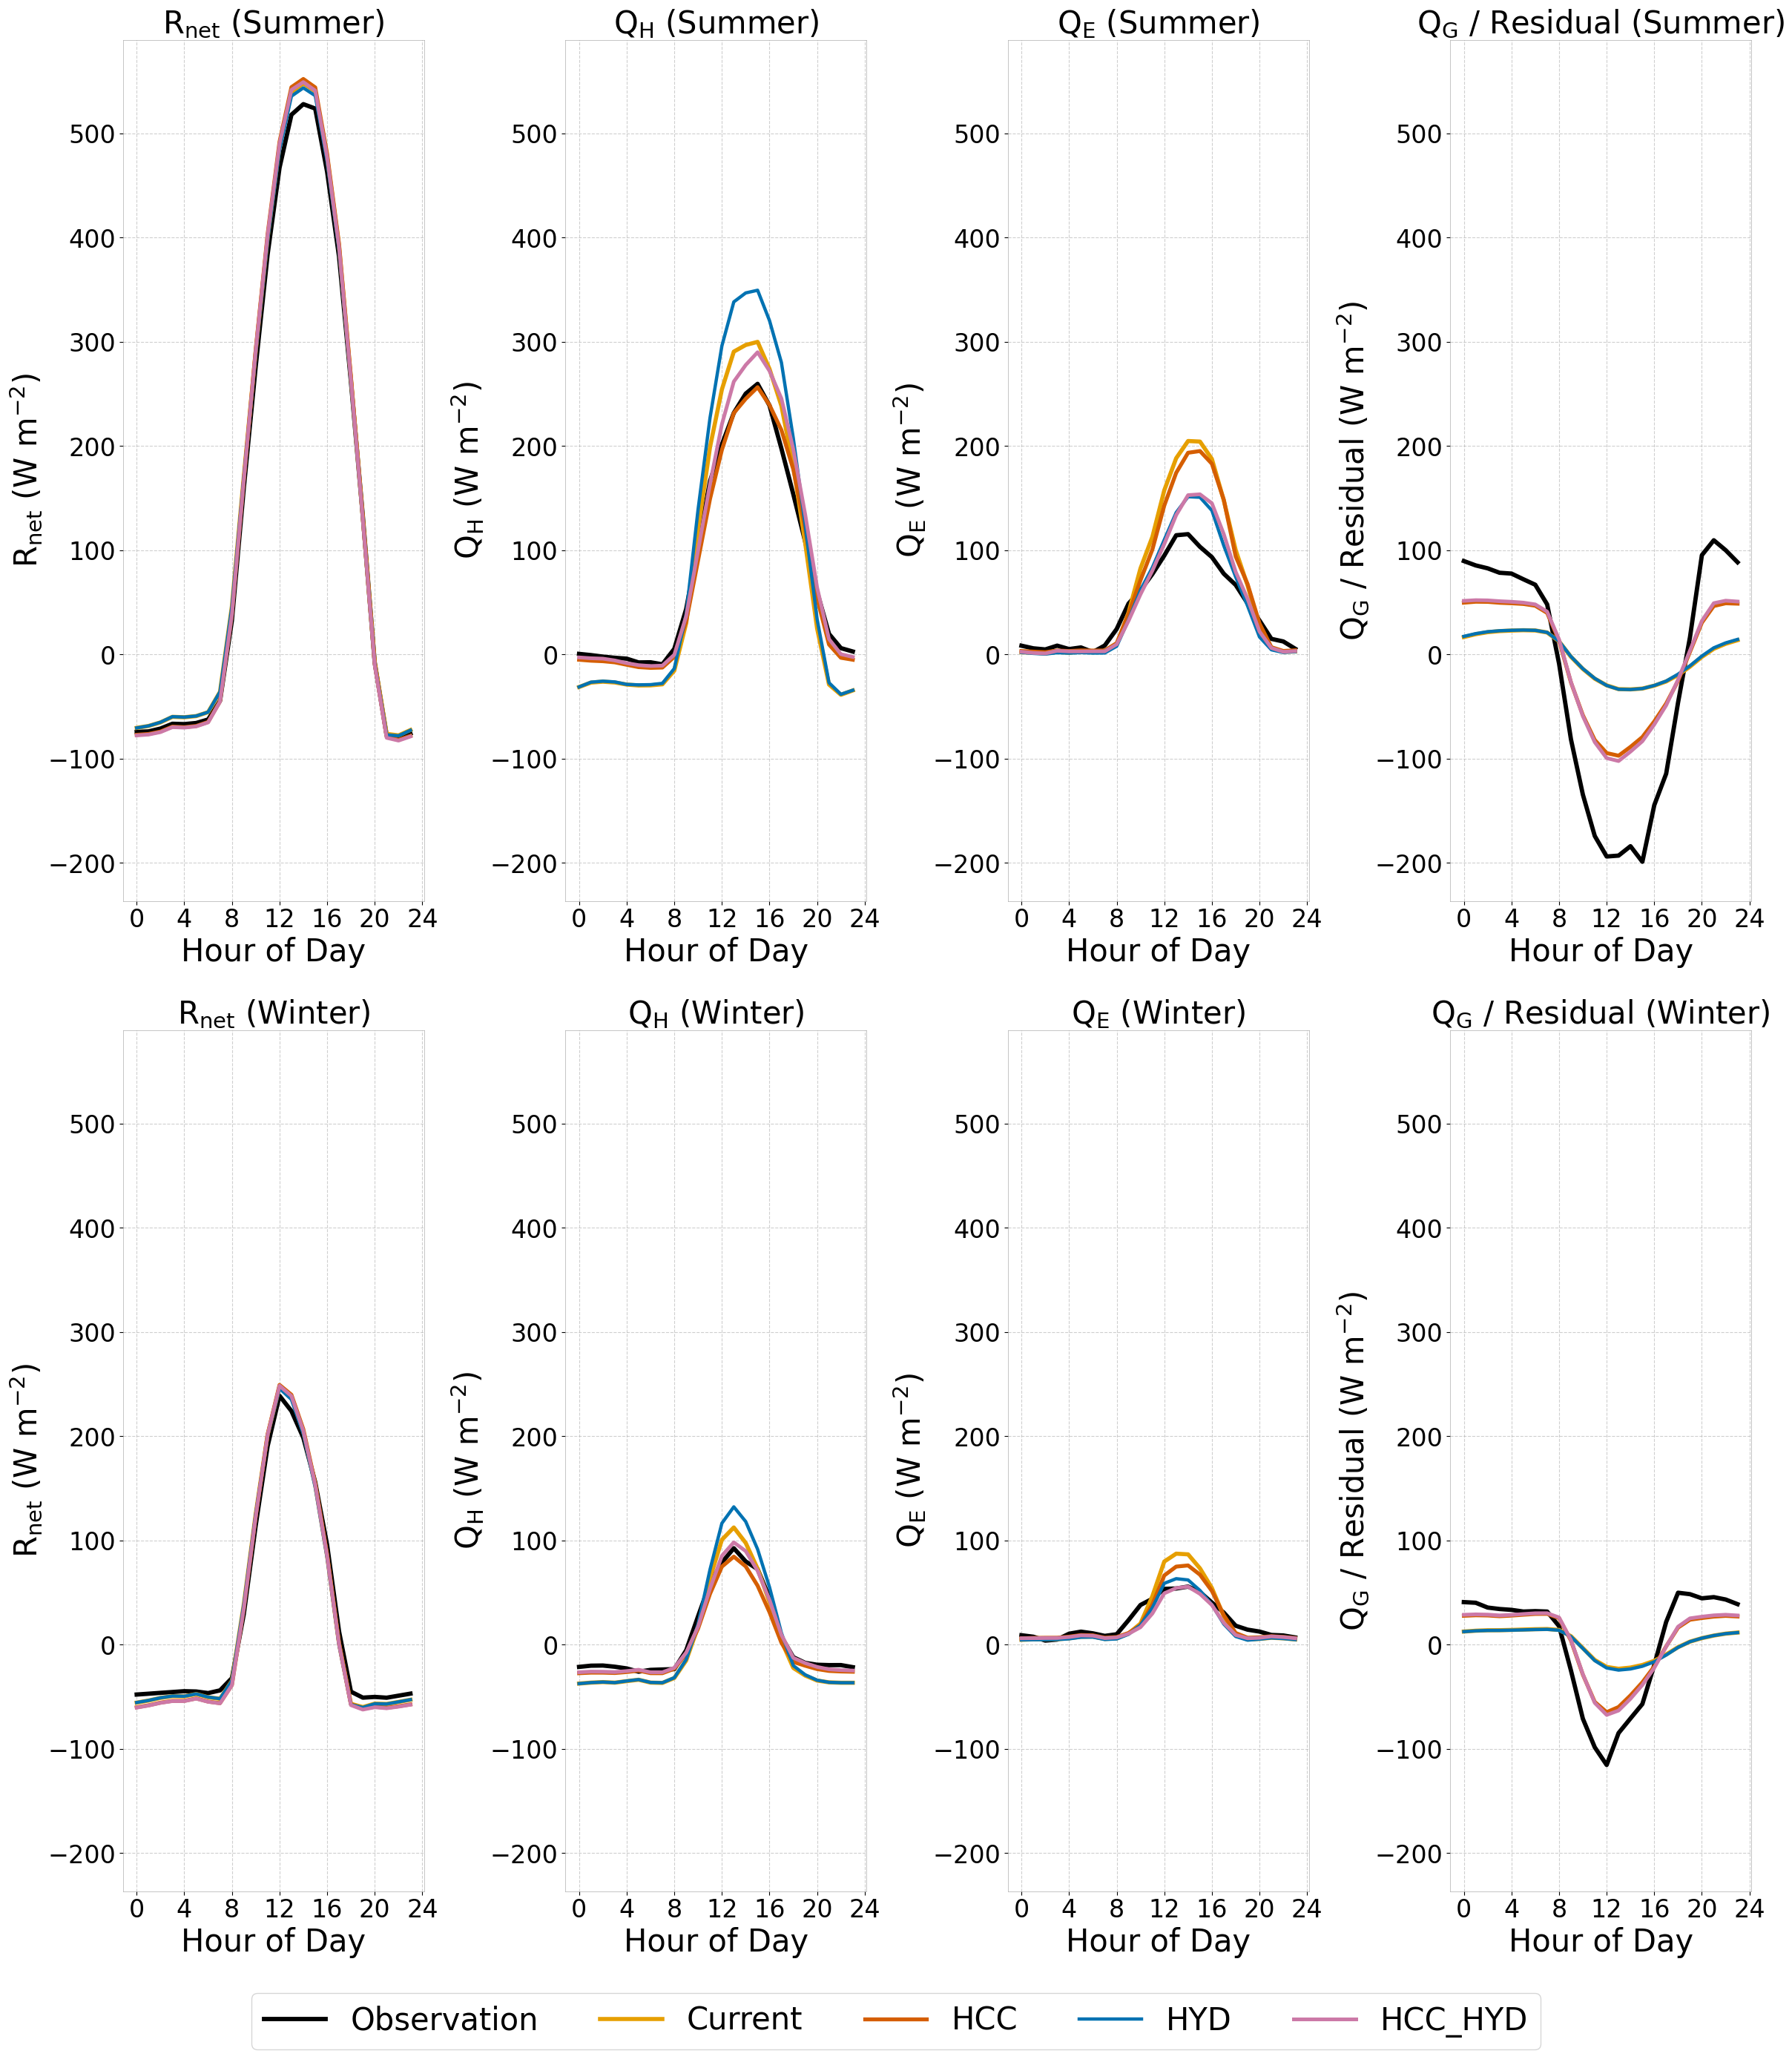

In [ ]:
# Plot eight graphs in one figure

datasets = [
    (au_preston_current_rnet_djf_diurnal, r"${\mathrm{R_{net}}}$ (Summer)", r"${\mathrm{R_{net}}}$ (W m$^{-2}$)", au_preston_obs_rnet_djf_diurnal, au_preston_hcc_rnet_djf_diurnal, au_preston_hyd_rnet_djf_diurnal, au_preston_hcc_hyd_rnet_djf_diurnal),
    (au_preston_current_qh_djf_diurnal, r"${\mathrm{Q_{H}}}$ (Summer)", r"${\mathrm{Q_{H}}}$ (W m$^{-2}$)", au_preston_obs_qh_djf_diurnal, au_preston_hcc_qh_djf_diurnal, au_preston_hyd_qh_djf_diurnal, au_preston_hcc_hyd_qh_djf_diurnal),
    (au_preston_current_qle_djf_diurnal, r"${\mathrm{Q_{E}}}$ (Summer)", r"${\mathrm{Q_{E}}}$ (W m$^{-2}$)", au_preston_obs_qle_djf_diurnal, au_preston_hcc_qle_djf_diurnal, au_preston_hyd_qle_djf_diurnal, au_preston_hcc_hyd_qle_djf_diurnal),
    (au_preston_current_qg_djf_diurnal, r"${\mathrm{Q_{G}}}$ / Residual (Summer)", r"${\mathrm{Q_{G}}}$ / Residual (W m$^{-2}$)", au_preston_obs_residual_djf_diurnal, au_preston_hcc_qg_djf_diurnal, au_preston_hyd_qg_djf_diurnal, au_preston_hcc_hyd_qg_djf_diurnal),
    (au_preston_current_rnet_jja_diurnal, r"${\mathrm{R_{net}}}$ (Winter)", r"${\mathrm{R_{net}}}$ (W m$^{-2}$)", au_preston_obs_rnet_jja_diurnal, au_preston_hcc_rnet_jja_diurnal, au_preston_hyd_rnet_jja_diurnal, au_preston_hcc_hyd_rnet_jja_diurnal),
    (au_preston_current_qh_jja_diurnal, r"${\mathrm{Q_{H}}}$ (Winter)", r"${\mathrm{Q_{H}}}$ (W m$^{-2}$)", au_preston_obs_qh_jja_diurnal, au_preston_hcc_qh_jja_diurnal, au_preston_hyd_qh_jja_diurnal, au_preston_hcc_hyd_qh_jja_diurnal),
    (au_preston_current_qle_jja_diurnal, r"${\mathrm{Q_{E}}}$ (Winter)", r"${\mathrm{Q_{E}}}$ (W m$^{-2}$)", au_preston_obs_qle_jja_diurnal, au_preston_hcc_qle_jja_diurnal, au_preston_hyd_qle_jja_diurnal, au_preston_hcc_hyd_qle_jja_diurnal),
    (au_preston_current_qg_jja_diurnal, r"${\mathrm{Q_{G}}}$ / Residual (Winter)", r"${\mathrm{Q_{G}}}$ / Residual (W m$^{-2}$)", au_preston_obs_residual_jja_diurnal, au_preston_hcc_qg_jja_diurnal, au_preston_hyd_qg_jja_diurnal, au_preston_hcc_hyd_qg_jja_diurnal)
]

# Create figure grid
fig, axes = plt.subplots(2,4, figsize=(24, 28), sharex=True, sharey=True) 
axes = axes.flatten()

lines = []

for i, (current, title, ylabel, obs, hcc, hyd, hcc_hyd) in enumerate(datasets):
    ax = axes[i]
      
    line_obs = obs.plot(ax=ax, label='Observation', color="black", linewidth=4.2)
    if i == 0:
        lines.append(line_obs[0])
    
    line_current = current.plot(ax=ax, label='Current', color="#E69F00", linewidth=4)
    if i == 0:
        lines.append(line_current[0])

    line_hcc = hcc.plot(ax=ax, label='HCC', color="#D55E00", linewidth=3.8)
    if i == 0:
        lines.append(line_hcc[0])

    line_hyd = hyd.plot(ax=ax, label='HYD', color="#0072B2", linewidth=3.2)
    if i == 0:
           lines.append(line_hyd[0])

    line_hcc_hyd = hcc_hyd.plot(ax=ax, label='HCC_HYD', color="#CC79A7", linewidth=3.6)
    if i == 0:
           lines.append(line_hcc_hyd[0])
    
    ax.set_title(title, fontsize=30)
    ax.set_xlabel("Hour of Day", fontsize=30)
    ax.set_ylabel(ylabel, fontsize=30)
    ax.set_xticks(range(0, 25, 4))
    ax.tick_params(axis='both', which='both', labelsize=24, labelbottom=True, labelleft=True)
    ax.grid(True, linestyle='--', alpha=0.6)

    # Make frames thinner and gray
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)
        spine.set_color('#999999')

# Make room at the bottom for the legend
plt.tight_layout(rect=[0, 0.05, 1, 1])

# Ensure enough space between first and second row
fig.subplots_adjust(hspace=0.15)

fig.legend(
    handles=lines,
    labels=['Observation', 'Current', 'HCC', 'HYD', 'HCC_HYD'],
    loc='lower center',
    ncol=5,                
    fontsize=30,
    frameon=True
)

plt.savefig("diurnal_cycles_qg.pdf", bbox_inches="tight")

plt.show()

In [45]:
# Radiative diagnostics

# Read in forcing data
au_preston_forcing = xr.open_dataset("/cluster/home/katepp/Urban-PLUMBER/AU-Preston/timeseries/AU-Preston_metforcing_v1.nc")
au_preston_forcing = au_preston_forcing.sel(time=slice('2003-08-12', '2004-10-31'))

In [46]:
# Get SW down and LW down forcing
au_preston_forcing_swd = au_preston_forcing.SWdown
au_preston_forcing_lwd = au_preston_forcing.LWdown

# Account for period-ending timestamps of Urban-Plumber forcing
au_preston_forcing_swd["time"] = au_preston_forcing_swd["time"] + np.timedelta64(30, "m")
au_preston_forcing_lwd["time"] = au_preston_forcing_lwd["time"] + np.timedelta64(30, "m")

In [47]:
# Get simulated SW and LW net radiation
au_preston_current_sw_net = au_preston_current.rad_sw_srf_net_box
au_preston_current_lw_net = au_preston_current.rad_lw_srf_net_box

au_preston_hcc_sw_net = au_preston_hcc.rad_sw_srf_net_box
au_preston_hcc_lw_net = au_preston_hcc.rad_lw_srf_net_box

au_preston_hyd_sw_net = au_preston_hyd.rad_sw_srf_net_box
au_preston_hyd_lw_net = au_preston_hyd.rad_lw_srf_net_box

au_preston_hcc_hyd_sw_net = au_preston_hcc_hyd.rad_sw_srf_net_box
au_preston_hcc_hyd_lw_net = au_preston_hcc_hyd.rad_lw_srf_net_box

In [48]:
# Calculate simulated SW up and LW up
au_preston_current_swu = au_preston_forcing_swd - au_preston_current_sw_net
au_preston_current_lwu = au_preston_forcing_lwd - au_preston_current_lw_net

au_preston_hcc_swu = au_preston_forcing_swd - au_preston_hcc_sw_net
au_preston_hcc_lwu = au_preston_forcing_lwd - au_preston_hcc_lw_net

au_preston_hyd_swu = au_preston_forcing_swd - au_preston_hyd_sw_net
au_preston_hyd_lwu = au_preston_forcing_lwd - au_preston_hyd_lw_net

au_preston_hcc_hyd_swu = au_preston_forcing_swd - au_preston_hcc_hyd_sw_net
au_preston_hcc_hyd_lwu = au_preston_forcing_lwd - au_preston_hcc_hyd_lw_net

In [49]:
# Calculate mean diurnal cycle of SW up for DJF
# Filter by DJF
is_djf_obs = au_preston_swu_for_rnet.time.dt.month.isin([12, 1, 2])
au_preston_swu_for_rnet_djf = au_preston_swu_for_rnet.sel(time=is_djf_obs)

is_djf_current = au_preston_current_swu.time.dt.month.isin([12, 1, 2])
au_preston_current_swu_djf = au_preston_current_swu.sel(time=is_djf_current)

is_djf_hcc = au_preston_hcc_swu.time.dt.month.isin([12, 1, 2])
au_preston_hcc_swu_djf = au_preston_hcc_swu.sel(time=is_djf_hcc)

is_djf_hyd = au_preston_hyd_swu.time.dt.month.isin([12, 1, 2])
au_preston_hyd_swu_djf = au_preston_hyd_swu.sel(time=is_djf_hyd)

is_djf_hcc_hyd = au_preston_hcc_hyd_swu.time.dt.month.isin([12, 1, 2])
au_preston_hcc_hyd_swu_djf = au_preston_hcc_hyd_swu.sel(time=is_djf_hcc_hyd)


# Convert to local time
local_time_index = (
    au_preston_swu_for_rnet_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_swu_for_rnet_djf["time"] = local_time_index.tz_localize(None) + np.timedelta64(30, "m") # add 30 min to account for period-ending timestamps of observations

local_time_index = (
    au_preston_current_swu_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_current_swu_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_swu_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_swu_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hyd_swu_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hyd_swu_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_hyd_swu_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_hyd_swu_djf["time"] = local_time_index.tz_localize(None)


# Calculate mean diurnal cycle
au_preston_swu_for_rnet_djf_diurnal = au_preston_swu_for_rnet_djf.groupby("time.hour").mean()

au_preston_current_swu_djf_diurnal = au_preston_current_swu_djf.groupby("time.hour").mean()

au_preston_hcc_swu_djf_diurnal = au_preston_hcc_swu_djf.groupby("time.hour").mean()

au_preston_hyd_swu_djf_diurnal = au_preston_hyd_swu_djf.groupby("time.hour").mean()

au_preston_hcc_hyd_swu_djf_diurnal = au_preston_hcc_hyd_swu_djf.groupby("time.hour").mean()

In [50]:
# Calculate mean diurnal cycle of SW up for JJA
# Filter by JJA
is_jja_obs = au_preston_swu_for_rnet.time.dt.month.isin([6, 7, 8])
au_preston_swu_for_rnet_jja = au_preston_swu_for_rnet.sel(time=is_jja_obs)

is_jja_current = au_preston_current_swu.time.dt.month.isin([6, 7, 8])
au_preston_current_swu_jja = au_preston_current_swu.sel(time=is_jja_current)

is_jja_hcc = au_preston_hcc_swu.time.dt.month.isin([6, 7, 8])
au_preston_hcc_swu_jja = au_preston_hcc_swu.sel(time=is_jja_hcc)

is_jja_hyd = au_preston_hyd_swu.time.dt.month.isin([6, 7, 8])
au_preston_hyd_swu_jja = au_preston_hyd_swu.sel(time=is_jja_hyd)

is_jja_hcc_hyd = au_preston_hcc_hyd_swu.time.dt.month.isin([6, 7, 8])
au_preston_hcc_hyd_swu_jja = au_preston_hcc_hyd_swu.sel(time=is_jja_hcc_hyd)


# Convert to local time
local_time_index = (
    au_preston_swu_for_rnet_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_swu_for_rnet_jja["time"] = local_time_index.tz_localize(None) + np.timedelta64(30, "m") # add 30 min to account for period-ending timestamps of observations

local_time_index = (
    au_preston_current_swu_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_current_swu_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_swu_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_swu_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hyd_swu_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hyd_swu_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_hyd_swu_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_hyd_swu_jja["time"] = local_time_index.tz_localize(None)


# Calculate mean diurnal cycle
au_preston_swu_for_rnet_jja_diurnal = au_preston_swu_for_rnet_jja.groupby("time.hour").mean()

au_preston_current_swu_jja_diurnal = au_preston_current_swu_jja.groupby("time.hour").mean()

au_preston_hcc_swu_jja_diurnal = au_preston_hcc_swu_jja.groupby("time.hour").mean()

au_preston_hyd_swu_jja_diurnal = au_preston_hyd_swu_jja.groupby("time.hour").mean()

au_preston_hcc_hyd_swu_jja_diurnal = au_preston_hcc_hyd_swu_jja.groupby("time.hour").mean()

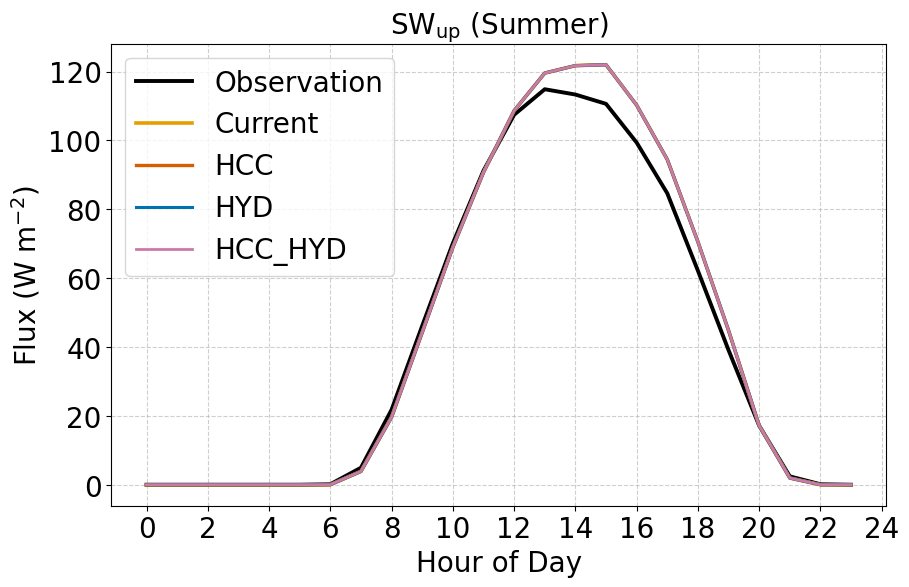

In [51]:
# Plot observations and simulations for SWup DJF

plt.figure(figsize=(10, 6))
au_preston_swu_for_rnet_djf_diurnal.plot(label='Observation', color="black", linewidth=2.8)
au_preston_current_swu_djf_diurnal.plot(label='Current', color="#E69F00", linewidth=2.6)
au_preston_hcc_swu_djf_diurnal.plot(label='HCC', color="#D55E00", linewidth=2.4)
au_preston_hyd_swu_djf_diurnal.plot(label='HYD', color="#0072B2", linewidth=2.2)
au_preston_hcc_hyd_swu_djf_diurnal.plot(label='HCC_HYD', color="#CC79A7", linewidth=2)
plt.title(r"${\mathrm{SW_{up}}}$ (Summer)", fontsize=20)
plt.xlabel("Hour of Day", fontsize=20)
plt.ylabel(r"Flux (W m$^{-2}$)", fontsize=20)
plt.xticks(range(0, 25, 2), fontsize=20) # Ensure labels every 2 hours
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=20)
plt.show()

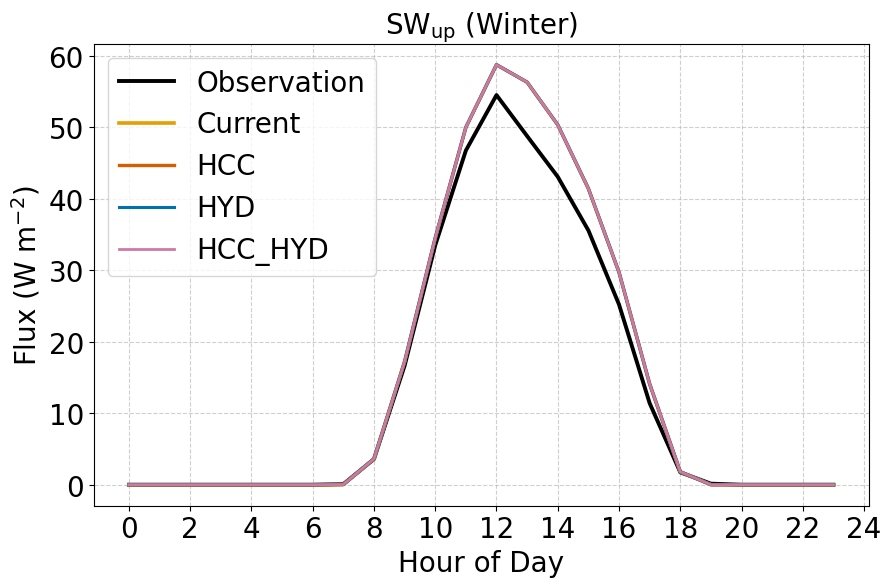

In [52]:
# Plot observations and simulations for SWup JJA

plt.figure(figsize=(10, 6))
au_preston_swu_for_rnet_jja_diurnal.plot(label='Observation', color="black", linewidth=2.8)
au_preston_current_swu_jja_diurnal.plot(label='Current', color="#E69F00", linewidth=2.6)
au_preston_hcc_swu_jja_diurnal.plot(label='HCC', color="#D55E00", linewidth=2.4)
au_preston_hyd_swu_jja_diurnal.plot(label='HYD', color="#0072B2", linewidth=2.2)
au_preston_hcc_hyd_swu_jja_diurnal.plot(label='HCC_HYD', color="#CC79A7", linewidth=2)
plt.title(r"${\mathrm{SW_{up}}}$ (Winter)", fontsize=20)
plt.xlabel("Hour of Day", fontsize=20)
plt.ylabel(r"Flux (W m$^{-2}$)", fontsize=20)
plt.xticks(range(0, 25, 2), fontsize=20) # Ensure labels every 2 hours
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=20)
plt.show()

In [53]:
# Calculate mean diurnal cycle of LW up for DJF
# Filter by DJF
is_djf_obs = au_preston_obs_lwu.time.dt.month.isin([12, 1, 2])
au_preston_obs_lwu_djf = au_preston_obs_lwu.sel(time=is_djf_obs)

is_djf_current = au_preston_current_lwu.time.dt.month.isin([12, 1, 2])
au_preston_current_lwu_djf = au_preston_current_lwu.sel(time=is_djf_current)

is_djf_hcc = au_preston_hcc_lwu.time.dt.month.isin([12, 1, 2])
au_preston_hcc_lwu_djf = au_preston_hcc_lwu.sel(time=is_djf_hcc)

is_djf_hyd = au_preston_hyd_lwu.time.dt.month.isin([12, 1, 2])
au_preston_hyd_lwu_djf = au_preston_hyd_lwu.sel(time=is_djf_hyd)

is_djf_hcc_hyd = au_preston_hcc_hyd_lwu.time.dt.month.isin([12, 1, 2])
au_preston_hcc_hyd_lwu_djf = au_preston_hcc_hyd_lwu.sel(time=is_djf_hcc_hyd)


# Convert to local time
local_time_index = (
    au_preston_obs_lwu_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_obs_lwu_djf["time"] = local_time_index.tz_localize(None) + np.timedelta64(30, "m") # add 30 min to account for period-ending timestamps of observations

local_time_index = (
    au_preston_current_lwu_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_current_lwu_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_lwu_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_lwu_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hyd_lwu_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hyd_lwu_djf["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_hyd_lwu_djf.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_hyd_lwu_djf["time"] = local_time_index.tz_localize(None)


# Calculate mean diurnal cycle
au_preston_obs_lwu_djf_diurnal = au_preston_obs_lwu_djf.groupby("time.hour").mean()

au_preston_current_lwu_djf_diurnal = au_preston_current_lwu_djf.groupby("time.hour").mean()

au_preston_hcc_lwu_djf_diurnal = au_preston_hcc_lwu_djf.groupby("time.hour").mean()

au_preston_hyd_lwu_djf_diurnal = au_preston_hyd_lwu_djf.groupby("time.hour").mean()

au_preston_hcc_hyd_lwu_djf_diurnal = au_preston_hcc_hyd_lwu_djf.groupby("time.hour").mean()

In [54]:
# Calculate mean diurnal cycle of LW up for JJA
# Filter by JJA
is_jja_obs = au_preston_obs_lwu.time.dt.month.isin([6, 7, 8])
au_preston_obs_lwu_jja = au_preston_obs_lwu.sel(time=is_jja_obs)

is_jja_current = au_preston_current_lwu.time.dt.month.isin([6, 7, 8])
au_preston_current_lwu_jja = au_preston_current_lwu.sel(time=is_jja_current)

is_jja_hcc = au_preston_hcc_lwu.time.dt.month.isin([6, 7, 8])
au_preston_hcc_lwu_jja = au_preston_hcc_lwu.sel(time=is_jja_hcc)

is_jja_hyd = au_preston_hyd_lwu.time.dt.month.isin([6, 7, 8])
au_preston_hyd_lwu_jja = au_preston_hyd_lwu.sel(time=is_jja_hyd)

is_jja_hcc_hyd = au_preston_hcc_hyd_lwu.time.dt.month.isin([6, 7, 8])
au_preston_hcc_hyd_lwu_jja = au_preston_hcc_hyd_lwu.sel(time=is_jja_hcc_hyd)


# Convert to local time
local_time_index = (
    au_preston_obs_lwu_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_obs_lwu_jja["time"] = local_time_index.tz_localize(None) + np.timedelta64(30, "m") # add 30 min to account for period-ending timestamps of observations

local_time_index = (
    au_preston_current_lwu_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_current_lwu_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_lwu_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_lwu_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hyd_lwu_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hyd_lwu_jja["time"] = local_time_index.tz_localize(None)

local_time_index = (
    au_preston_hcc_hyd_lwu_jja.time.to_index()
    .tz_localize("UTC")
    .tz_convert("Australia/Melbourne")  # UTC+10/11
)
au_preston_hcc_hyd_lwu_jja["time"] = local_time_index.tz_localize(None)


# Calculate mean diurnal cycle
au_preston_obs_lwu_jja_diurnal = au_preston_obs_lwu_jja.groupby("time.hour").mean()

au_preston_current_lwu_jja_diurnal = au_preston_current_lwu_jja.groupby("time.hour").mean()

au_preston_hcc_lwu_jja_diurnal = au_preston_hcc_lwu_jja.groupby("time.hour").mean()

au_preston_hyd_lwu_jja_diurnal = au_preston_hyd_lwu_jja.groupby("time.hour").mean()

au_preston_hcc_hyd_lwu_jja_diurnal = au_preston_hcc_hyd_lwu_jja.groupby("time.hour").mean()

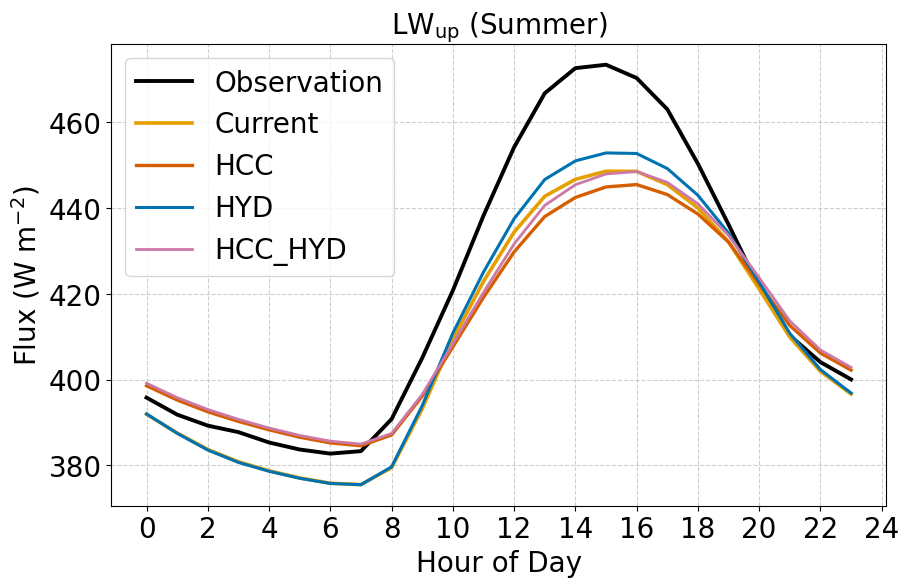

In [55]:
# Plot observations and simulations for LWup DJF

plt.figure(figsize=(10, 6))
au_preston_obs_lwu_djf_diurnal.plot(label='Observation', color="black", linewidth=2.8)
au_preston_current_lwu_djf_diurnal.plot(label='Current', color="#E69F00", linewidth=2.6)
au_preston_hcc_lwu_djf_diurnal.plot(label='HCC', color="#D55E00", linewidth=2.4)
au_preston_hyd_lwu_djf_diurnal.plot(label='HYD', color="#0072B2", linewidth=2.2)
au_preston_hcc_hyd_lwu_djf_diurnal.plot(label='HCC_HYD', color="#CC79A7", linewidth=2)
plt.title(r"${\mathrm{LW_{up}}}$ (Summer)", fontsize=20)
plt.xlabel("Hour of Day", fontsize=20)
plt.ylabel(r"Flux (W m$^{-2}$)", fontsize=20)
plt.xticks(range(0, 25, 2), fontsize=20) # Ensure labels every 2 hours
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=20)
plt.show()

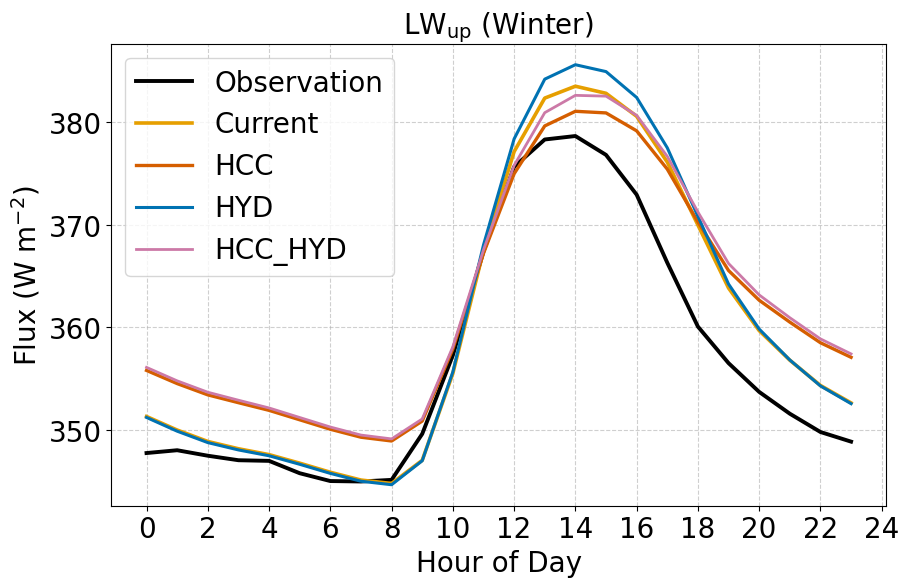

In [56]:
# Plot observations and simulations for LWup JJA

plt.figure(figsize=(10, 6))
au_preston_obs_lwu_jja_diurnal.plot(label='Observation', color="black", linewidth=2.8)
au_preston_current_lwu_jja_diurnal.plot(label='Current', color="#E69F00", linewidth=2.6)
au_preston_hcc_lwu_jja_diurnal.plot(label='HCC', color="#D55E00", linewidth=2.4)
au_preston_hyd_lwu_jja_diurnal.plot(label='HYD', color="#0072B2", linewidth=2.2)
au_preston_hcc_hyd_lwu_jja_diurnal.plot(label='HCC_HYD', color="#CC79A7", linewidth=2)
plt.title(r"${\mathrm{LW_{up}}}$ (Winter)", fontsize=20)
plt.xlabel("Hour of Day", fontsize=20)
plt.ylabel(r"Flux (W m$^{-2}$)", fontsize=20)
plt.xticks(range(0, 25, 2), fontsize=20) # Ensure labels every 2 hours
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=20)
plt.show()

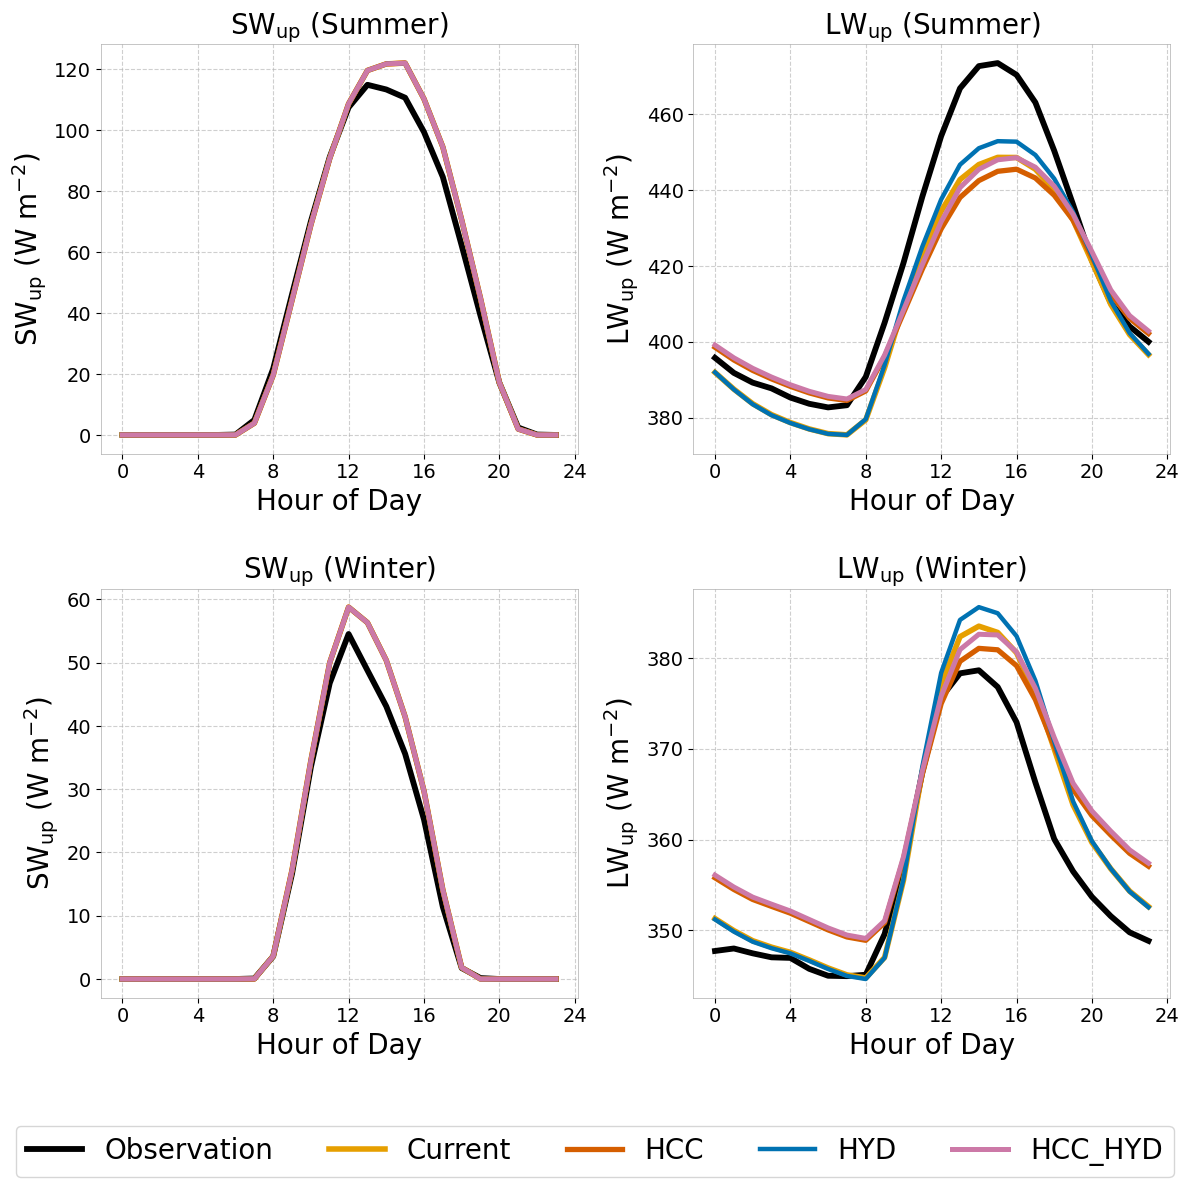

In [ ]:
# Plot four graphs in one figure (radiative diagnostics)

datasets = [
    (au_preston_current_swu_djf_diurnal, r"${\mathrm{SW_{up}}}$ (Summer)", r"${\mathrm{SW_{up}}}$ (W m$^{-2}$)", au_preston_swu_for_rnet_djf_diurnal, au_preston_hcc_swu_djf_diurnal, au_preston_hyd_swu_djf_diurnal, au_preston_hcc_hyd_swu_djf_diurnal),
    (au_preston_current_lwu_djf_diurnal, r"${\mathrm{LW_{up}}}$ (Summer)", r"${\mathrm{LW_{up}}}$ (W m$^{-2}$)", au_preston_obs_lwu_djf_diurnal, au_preston_hcc_lwu_djf_diurnal, au_preston_hyd_lwu_djf_diurnal, au_preston_hcc_hyd_lwu_djf_diurnal),
    (au_preston_current_swu_jja_diurnal, r"${\mathrm{SW_{up}}}$ (Winter)", r"${\mathrm{SW_{up}}}$ (W m$^{-2}$)", au_preston_swu_for_rnet_jja_diurnal, au_preston_hcc_swu_jja_diurnal, au_preston_hyd_swu_jja_diurnal, au_preston_hcc_hyd_swu_jja_diurnal),
    (au_preston_current_lwu_jja_diurnal, r"${\mathrm{LW_{up}}}$ (Winter)", r"${\mathrm{LW_{up}}}$ (W m$^{-2}$)", au_preston_obs_lwu_jja_diurnal, au_preston_hcc_lwu_jja_diurnal, au_preston_hyd_lwu_jja_diurnal, au_preston_hcc_hyd_lwu_jja_diurnal)
]

# Create figure grid
fig, axes = plt.subplots(2,2, figsize=(12, 12)) 
axes = axes.flatten()

lines = []

for i, (current, title, ylabel, obs, hcc, hyd, hcc_hyd) in enumerate(datasets):
    ax = axes[i]
      
    line_obs = obs.plot(ax=ax, label='Observation', color="black", linewidth=4.2)
    if i == 0:
        lines.append(line_obs[0])
    
    line_current = current.plot(ax=ax, label='Current', color="#E69F00", linewidth=4)
    if i == 0:
        lines.append(line_current[0])

    line_hcc = hcc.plot(ax=ax, label='HCC', color="#D55E00", linewidth=3.8)
    if i == 0:
        lines.append(line_hcc[0])

    line_hyd = hyd.plot(ax=ax, label='HYD', color="#0072B2", linewidth=3.2)
    if i == 0:
           lines.append(line_hyd[0])

    line_hcc_hyd = hcc_hyd.plot(ax=ax, label='HCC_HYD', color="#CC79A7", linewidth=3.6)
    if i == 0:
           lines.append(line_hcc_hyd[0])
    
    ax.set_title(title, fontsize=20)
    ax.set_xlabel("Hour of Day", fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.set_xticks(range(0, 25, 4))
    ax.tick_params(axis='both', which='both', labelsize=14, labelbottom=True, labelleft=True)
    ax.grid(True, linestyle='--', alpha=0.6)

    # Make frames thinner and gray
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)
        spine.set_color('#999999')

# Make room at the bottom for the legend
plt.tight_layout(rect=[0, 0.1, 1, 1])

# Ensure enough space between first and second row
fig.subplots_adjust(hspace=0.33)

fig.legend(
    handles=lines,
    labels=['Observation', 'Current', 'HCC', 'HYD', 'HCC_HYD'],
    loc='lower center',    
    ncol=5,                
    fontsize=20,
    frameon=True
)

plt.savefig("radiative_diagnostics.pdf", bbox_inches="tight")

plt.show()